In [30]:
import urllib.request
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:

# Remove the filter to get actual data
url = 'https://opendata.muenchen.de/api/3/action/datastore_search?resource_id=40094bd6-f82d-4979-949b-26c8dc00b9a7&limit=100'

# Fetch and parse the JSON data
with urllib.request.urlopen(url) as response:
    data = response.read()
    parsed = json.loads(data)


In [8]:
# Extract the records (tabular data)
records = parsed['result']['records']

# Convert to DataFrame
data = pd.DataFrame(records)

In [9]:
data

,_id,MONATSZAHL,AUSPRAEGUNG,JAHR,MONAT,WERT,VORJAHRESWERT,VERAEND_VORMONAT_PROZENT,VERAEND_VORJAHRESMONAT_PROZENT,ZWOELF_MONATE_MITTELWERT
0,1,Alkoholunfälle,insgesamt,2024,202401,NaN,NaN,None,None,None
1,2,Alkoholunfälle,insgesamt,2024,202402,NaN,NaN,None,None,None
2,3,Alkoholunfälle,insgesamt,2024,202403,NaN,NaN,None,None,None
3,4,Alkoholunfälle,insgesamt,2024,202404,NaN,NaN,None,None,None
4,5,Alkoholunfälle,insgesamt,2024,202405,NaN,NaN,None,None,None
...,...,...,...,...,...,...,...,...,...,...
95,96,Alkoholunfälle,insgesamt,2017,201706,41.0,30.0,41.38,36.67,28
96,97,Alkoholunfälle,insgesamt,2017,201707,52.0,35.0,26.83,48.57,30
97,98,Alkoholunfälle,insgesamt,2017,201708,30.0,34.0,-42.31,-11.76,30
98,99,Alkoholunfälle,insgesamt,2017,201709,47.0,29.0,56.67,62.07,31


In [10]:
max=data['JAHR'].max()
min=data['JAHR'].max()

In [11]:
min


np.int64(2024)

In [12]:
max

np.int64(2024)

In [13]:
data.columns

Index(['_id', 'MONATSZAHL', 'AUSPRAEGUNG', 'JAHR', 'MONAT', 'WERT',
       'VORJAHRESWERT', 'VERAEND_VORMONAT_PROZENT',
       'VERAEND_VORJAHRESMONAT_PROZENT', 'ZWOELF_MONATE_MITTELWERT'],
      dtype='object')

In [15]:

data = data[data['JAHR'] <= 2020]


In [16]:
filtered_data = data[['MONATSZAHL', 'AUSPRAEGUNG', 'JAHR', 'MONAT', 'WERT']]

# Optionally rename for clarity
filtered_data = filtered_data.rename(columns={
    'MONATSZAHL': 'Category',
    'AUSPRAEGUNG': 'Accident_Type',
    'JAHR': 'Year',
    'MONAT': 'Month',
    'WERT': 'Value'
})

In [18]:
filtered_data.isna().sum()

Category         0
Accident_Type    0
Year             0
Month            0
Value            0
dtype: int64

In [21]:
(filtered_data == 0).any()


Category         False
Accident_Type    False
Year             False
Month            False
Value            False
dtype: bool

In [22]:
collection=filtered_data.groupby(['Year','Category']).sum().reset_index()

In [29]:
collection

,Year,Category,Accident_Type,Month,Value
0,2017,Alkoholunfälle,insgesamtinsgesamtinsgesamtinsgesamtinsgesamti...,Summe20170120170220170320170420170520170620170...,743.0
1,2018,Alkoholunfälle,insgesamtinsgesamtinsgesamtinsgesamtinsgesamti...,Summe20180120180220180320180420180520180620180...,796.0
2,2019,Alkoholunfälle,insgesamtinsgesamtinsgesamtinsgesamtinsgesamti...,Summe20190120190220190320190420190520190620190...,868.0
3,2020,Alkoholunfälle,insgesamtinsgesamtinsgesamtinsgesamtinsgesamti...,Summe20200120200220200320200420200520200620200...,860.0


In [36]:
min=collection['Year'].min()
max=collection['Year'].max()

In [31]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

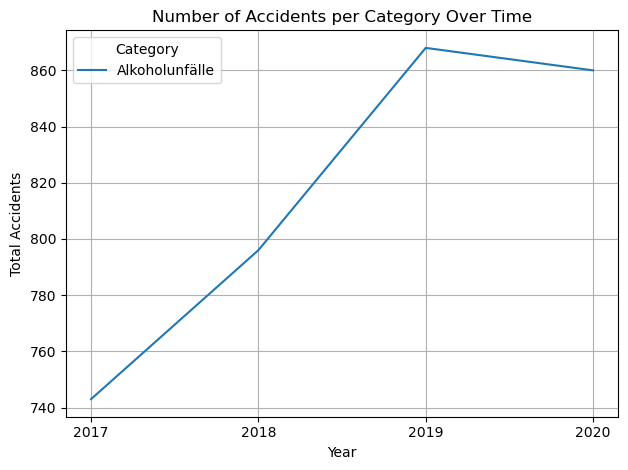

In [37]:
sns.lineplot(data=collection, x='Year', y='Value', hue='Category')
plt.title('Number of Accidents per Category Over Time')
plt.ylabel('Total Accidents')
plt.grid(True)
plt.tight_layout()
plt.xticks(ticks=range(min,max + 1))
plt.show()